# Factor Validation

En este notebook se analizan las propiedades estadísticas y temporales de los factores construidos en la fase de *Feature Engineering*.

El objetivo es evaluar la calidad, estabilidad, persistencia y redundancia de cada factor antes de su utilización en modelos de selección de activos y construcción de carteras.

Los resultados obtenidos servirán para justificar las decisiones de preprocesamiento (winsorización, normalización, etc.) y la posible eliminación de factores redundantes.

In [87]:
import sys
from pathlib import Path
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

# adds the root carpet of the project to the sys.path to allow importing modules from src
sys.path.append(str(Path.cwd().parent))

# autoreload configuration to automatically reload modules when they are modified
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Carga de Datos e inspección

In [88]:
prices = pd.read_parquet("../data/raw/sp500_prices.parquet")

# base variables
simple_returns = pd.read_parquet("../data/processed/simple_returns.parquet")
log_returns = pd.read_parquet("../data/processed/log_returns.parquet")
cumulative_returns = pd.read_parquet("../data/processed/cumulative_returns.parquet")

# style factors
momentum_12_1 = pd.read_parquet("../data/processed/momentum_12_1.parquet")
short_term_reversal = pd.read_parquet("../data/processed/short_term_reversal.parquet")
rolling_volatility = pd.read_parquet("../data/processed/rolling_volatility.parquet")
upside_volatility = pd.read_parquet("../data/processed/upside_volatility.parquet")
downside_volatility = pd.read_parquet("../data/processed/downside_volatility.parquet")
amihud_illiquidity = pd.read_parquet("../data/processed/amihud_illiquidity.parquet")


### 1.1 Información general por factor

In [89]:
factors = {
    "momentum_12_1": momentum_12_1,
    "short_term_reversal": short_term_reversal,
    "rolling_volatility": rolling_volatility,
    "upside_volatility": upside_volatility,
    "downside_volatility": downside_volatility,
    "amihud_illiquidity": amihud_illiquidity,
}

for name, df in factors.items():
    print(f"{name}")
    df.info()
    print("-" * 80)



momentum_12_1
<class 'pandas.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Columns: 499 entries, A to ZTS
dtypes: float64(499)
memory usage: 14.4 MB
--------------------------------------------------------------------------------
short_term_reversal
<class 'pandas.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Columns: 499 entries, A to ZTS
dtypes: float64(499)
memory usage: 14.4 MB
--------------------------------------------------------------------------------
rolling_volatility
<class 'pandas.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Columns: 499 entries, A to ZTS
dtypes: float64(499)
memory usage: 14.4 MB
--------------------------------------------------------------------------------
upside_volatility
<class 'pandas.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Columns: 499 entries, A to ZTS
dtypes: float64(499)
memory usage: 14.4 MB
------------------------------------------------------------------

## 2. Análisis de Cobertura y Calidad de Datos (Data Quality)

   - Porcentaje de valores nulos (NaNs) por factor y por fecha.
   - Nº de activos válidos en la cross-section a lo largo del tiempo.
   - Identificación de sesgo de supervivencia o inicio de series (Warm-up period por rolling windows).

### 2.1 Matriz de cobertura por factor y warm-up days

In [90]:
from src.analysis.factor_diagnostics import get_warmup_trading_days 

factors = {
    "momentum_12_1": momentum_12_1,
    "short_term_reversal": short_term_reversal,
    "rolling_volatility": rolling_volatility,
    "upside_volatility": upside_volatility,
    "downside_volatility": downside_volatility,
    "amihud_illiquidity": amihud_illiquidity,
}

summary = pd.DataFrame(
    [
        {
            "factor": name,
            "total_values": df.size,
            "valid_values": df.notna().sum().sum(),
            "nan_percentage": df.isna().sum().sum() / df.size * 100,
            "global_start_date": (
                df.index.get_level_values("Date")[df.notna().any(axis=1)].min()
            ),
            "global_end_date": (
                df.index.get_level_values("Date")[df.notna().any(axis=1)].max()
            ),
            "warmup_trading_days": get_warmup_trading_days(df),
        }
        for name, df in factors.items()
    ]
).set_index("factor")

summary["nan_percentage"] = summary["nan_percentage"].round(2)

summary

,total_values,valid_values,nan_percentage,global_start_date,global_end_date,warmup_trading_days
factor,,,,,,
momentum_12_1,1882727,1644211,12.67,2011-01-03,2024-12-30,252
short_term_reversal,1882727,1759361,6.55,2010-02-03,2024-12-30,21
rolling_volatility,1882727,1644211,12.67,2011-01-03,2024-12-30,252
upside_volatility,1882727,1747377,7.19,2010-02-16,2024-12-30,29
downside_volatility,1882727,1745649,7.28,2010-02-12,2024-12-30,28
amihud_illiquidity,1882727,1757181,6.67,2010-01-26,2024-12-30,15


Como era de esperar, los warming up days del Momentum y de la Rolling volatility son de un año completo ya que ambos factores se han definido con una ventana de 252 días. Concretamente en el caso del Momentum, este factor calculado el día t necesita el precio del día $(t-252)$ por lo que esos warm-up days son insalvables. 

En el caso de la rolling volatility sí que se podría haber definido un periodo mínimo de 30 o 60 días para poder calcular un valor de la Volatilidad sin la necesidad de que pase un año completo, pero, aprovechando que este factor no tiene valores NaN internos y que tenemos varios años de datos para todas las empresas, hemos exigido que todos los 252 periodos tengan datos para calcular el factor. La consecuencia obviamente es que los primeros 251 días de cotización de la empresa no tendremos un valor para la volatilidad, pero cuando lo tengamos nos habremos asegurado de que es lo suficientemente sólido y robusto. 

En el caso de Amihud Illiquidity sí que hemos elegido un periodo mínimo de 15 días para una ventana de 21 y en el caso del Short Term Reversal el cálculo nos exige el lag 21 por lo que tampoco tenemos opción. 

Por último las dos volatilidades (Upside y Downside) funcionan con una ventana de 252 días pero con un periodo mínimo de 21 días ya que, como cada una solamente tiene en cuenta los retornos de un signo

### 2.2 Análisis de cobertura por factor

A continuación se muestra gráficamente la evolución temporal del número de empresas disponibles para cada uno de los factores. Como todos ellos siguen prácticamente la misma evolución se ha considerado, a modo de representación, dos factores que obedezcan los dos rangos de warm up days que tenemos (1 mes y 1 año). Concretamente se ha elegido el Momentum y el Anihud Illiquidity. 

El número de puntos corresponde a uno por mes, siendo este el valor del último día de su mes correspondiente. 

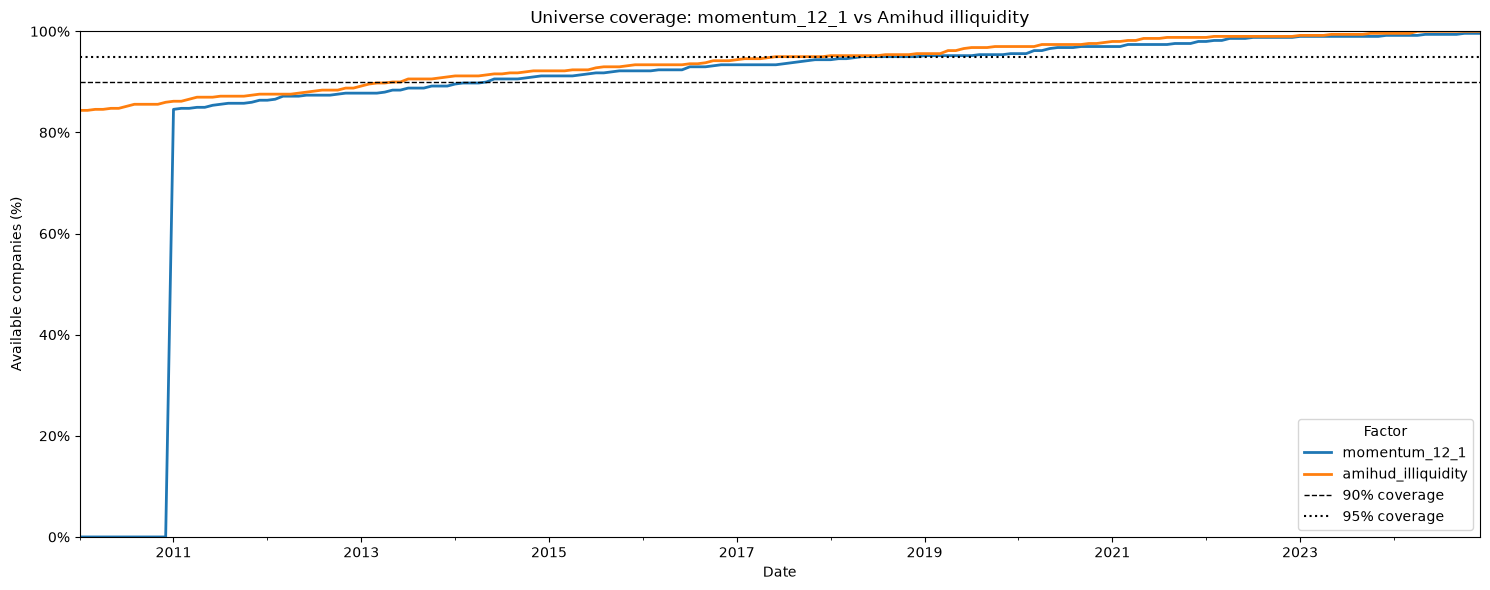

In [91]:
from src.analysis.factor_diagnostics import factor_coverage_since_first_valid

selected_factors = {
    "momentum_12_1": momentum_12_1,
    "amihud_illiquidity": amihud_illiquidity,
}

daily_factor_coverage = pd.DataFrame(
    {
        name: factor_coverage_since_first_valid(df, total_companies=499)
        for name, df in selected_factors.items()
    }
)

monthly_factor_coverage = daily_factor_coverage.resample("ME").last()

ax = monthly_factor_coverage.plot(
    figsize=(15, 6),
    linewidth=2,
    ylabel="Available companies (%)",
    title="Universe coverage: momentum_12_1 vs Amihud illiquidity",
)

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.legend(title="Factor")

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

ax.axhline(y=90, color="black", linestyle="--", linewidth=1, label="90% coverage")
ax.axhline(y=95, color="black", linestyle=":", linewidth=1.5, label="95% coverage")

ax.legend(title="Factor")


plt.tight_layout()
plt.show()

La diferencia en el número de warm up days entre los dos factores se ve clara ya que se muestra que prácticamente hasta 2011 el Momentum no tiene ninguna empresa disponible mientras que el Amihud Illiquidity comienza a rodar desde más del 80%. La subida vertical corresponde al día en el que la gran mayoría de empresas cumplieron los 252 días cotizados y se ve cómo a partir de ese momento los dos factores crecen en porcentaje de empresas disponibles de forma paulatina y al mismo ritmo. 

Entre el 2013 y el 2015 se llega al 90% de empresas disponibles y entre 2017 y 2019 se alcanza el 95%. 

### 2.3 Análisis de los valores NaN

Analizaremos en profundidad la cantidad y la distribución de los valores NaN dentro de las series de nuestros factores. 

In [92]:
from src.analysis.factor_diagnostics import internal_nan_count_by_ticker

print("Total NaNs after first valid by ticker:")

nans_by_factor = pd.Series(
    {
        name: internal_nan_count_by_ticker(df).sum()
        for name, df in factors.items()
    },
    name="nans_after_first_valid_by_ticker",
)

nans_by_factor

Total NaNs after first valid by ticker:


momentum_12_1             0
short_term_reversal       0
rolling_volatility        0
upside_volatility      1047
downside_volatility    1219
amihud_illiquidity     4190
Name: nans_after_first_valid_by_ticker, dtype: int64

Para los tres primeros factores (momentum, short term reversal y rolling volatility) observamos justo lo esperado, cero valores NaN internos. Es decir que, todos los NaN se acumulan al principio de la serie y no encontramos ninguna a partir del primer valor válido para cada Ticker. Realmente esto ya lo medio comprobamos al validar la data ya que nos aseguramos que no encontrábamos en el data frame de precios ningún NaN interno. 

Por otro lado sí que vamos a obervar NaNs en el upside y downside volatility y en el amihud illiquidity. Esto tiene sentido ya que la upside y downside volatility se calculan teniendo en cuenta una ventana de 252 días poniendo de restricción un mínimo de 21 días válidos. Por lo tanto, si entramos en una mala racha en el que hay muchos días seguidos con retornos negativos, la Upside volatility va a empezar a dar valores NaN. 

En el tema del Amihud Iliquidity, esos valores NaN se explican por los volúmenes nulos. La función tiene como restricción que solo se pueda dar un valor válido si de la ventana de 21 días que considera, al menos 15 son válidos, por el contrario daría NaN. 

A pesar de que podamos considerar que la cantidad de NaNs en los tres factores es suficientemente pequeña en comparación a la cantidad de valores que manejamos, realizaremos un análisis exhaustivo en ambas dimensiones: temporal y cross-sectional. 

####  2.3.1 Análisis temporal (NaNs por día y por trimestre)

En primer lugar, vamos a graficar el número de NaNs diarios (sumando los de todas las empresas) para el Upside y para el Downdside Volatility. Así podremos ver la evolución del porcentaje de NaNs en el tiempo. 

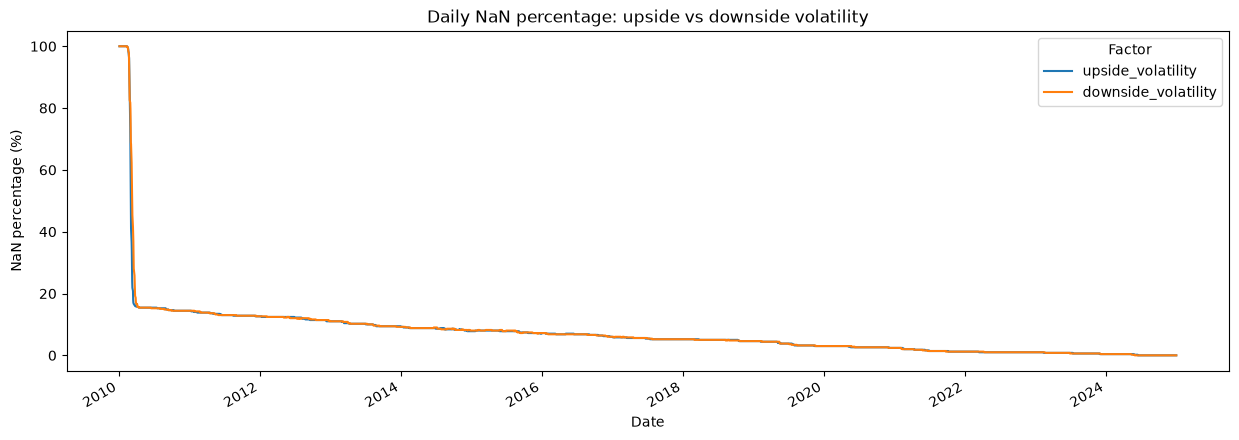

In [ ]:
daily_nan_comparison_pct = pd.DataFrame(
    {
        "upside_volatility": (
            upside_volatility.isna().sum(axis=1)
            / upside_volatility.shape[1]
            * 100
        ),
        "downside_volatility": (
            downside_volatility.isna().sum(axis=1)
            / downside_volatility.shape[1]
            * 100
        ),
    }
)

ax = daily_nan_comparison_pct.plot(
    kind="line",
    figsize=(15, 5),
    linewidth=1.5,
    ylabel="NaN percentage (%)",
    title="Daily NaN percentage: upside vs downside volatility",
)

ax.legend(title="Factor")
plt.show()

Vemos exactamente lo que se esperaba: el primer mes el porcentaje de NaNs es del 100% ya que ninguna empresa, a pesar de empezar a cotizar el día uno, tiene el suficiente número de días como para que los indicadores de Upside y Donside Volatility den un valor distinto del NaN. 

Se ve justamente que al pasar esa barrera de los 29 y 28 días respectivamente, el número de NaNs de las dos volatilidades caen en picado hasta situarse por debajo del 20%. Esto se explica porque la gran mayoría de las empresas de nuestro Universo ya estaban cotizando desde el primer día que consideramso como inicio del intervalo con el que trabajamos. Después se ve cómo progresivamente el número de NaNs va cayendo hasta llegar en 2024 a menos del 10%. 

Sin embargo, lo único que podemos concluir a partir de este gráfico es que la gran mayoría de NaNs provienen del tiempo en el que las empresas no cotizaban, es decir, que la proporción de NaNs internos es bastante inferior a la de NaNs antes de cotización. Realmente para poder ver la distribución de los NaNs internos tenemos que no considerar el otro tipo. 

El siguiente gráfico agrupa por trimestres el número de NaNs presentes en cada una de las volatilidades. La diferencia es que ahora solamente se contabilizan los NaNs de las empresas que ya han tenido al menos un día de cotización distinto del NaN, así nos aseguramos de solo incluir los internos. 

<Axes: title={'center': 'Quarterly internal NaNs: upside vs downside volatility'}, xlabel='Date', ylabel='Internal NaN count'>

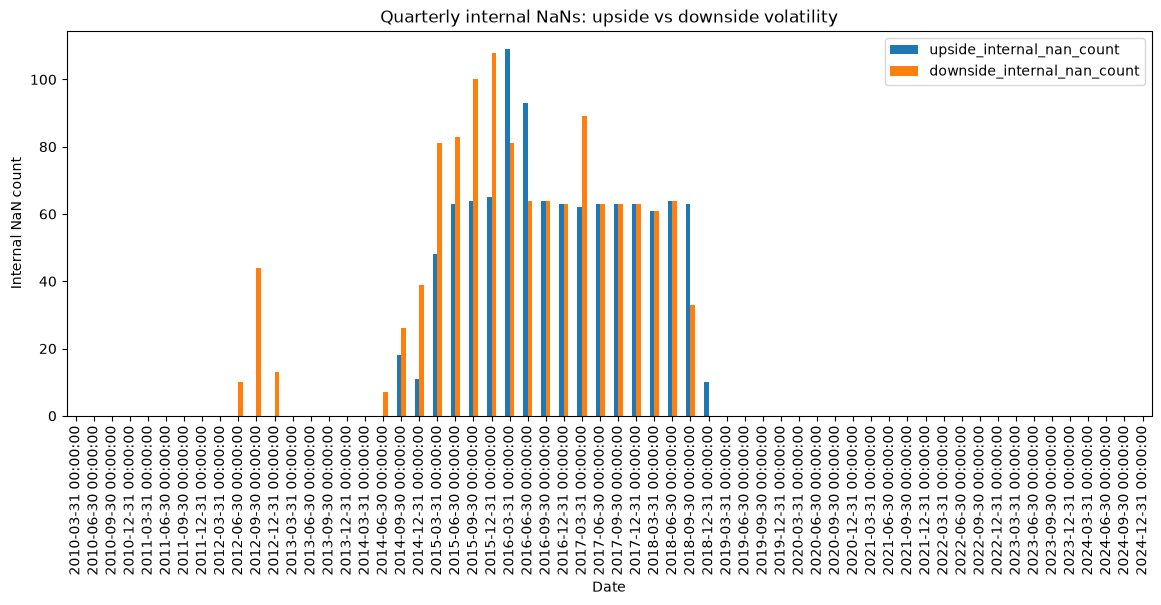

In [94]:
from src.analysis.factor_diagnostics import internal_nans_by_quarter

upside_quarterly = internal_nans_by_quarter(upside_volatility).add_prefix("upside_")
downside_quarterly = internal_nans_by_quarter(downside_volatility).add_prefix("downside_")

volatility_nan_comparison = pd.concat(
    [upside_quarterly, downside_quarterly],
    axis=1,
)

volatility_nan_comparison[
    ["upside_internal_nan_count", "downside_internal_nan_count"]
].plot(
    kind="bar",
    figsize=(14, 5),
    ylabel="Internal NaN count",
    title="Quarterly internal NaNs: upside vs downside volatility",
)

Observamos que el número de NaNs por trimestres se concentran entre el año 2014 y 2017. Después cuando analicemos la otra dimension (en vez de temporal, por empresa) obtendremos más información. 

Igualmente estos números no preocupan ya que el máximos de NaNs que llegamos a tener en un trimestre son de en torno a unos 100 para ambos factores y teniendo en cuenta que en un trimestre tenemos por factor unas 30000 observaciones (63 días por las 499 empresas), la proporción es ridícula. 


Realizaremos la misma gráfica para el último factor Amihud Illiquidity para ver la evolución temporal del número de NaNs.  

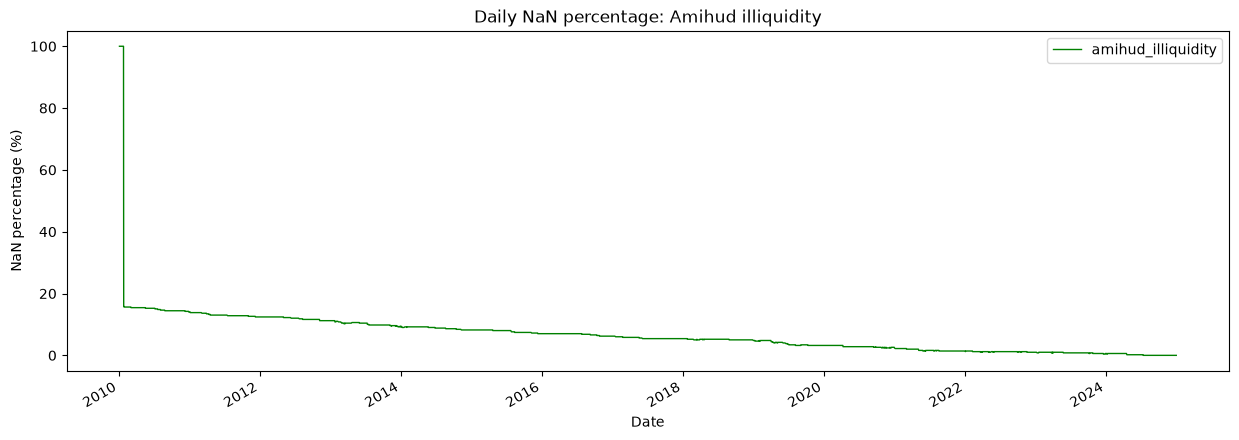

In [95]:
daily_amihud_nan_pct = (
    amihud_illiquidity.isna().sum(axis=1)
    / amihud_illiquidity.shape[1]
    * 100
)

ax = daily_amihud_nan_pct.plot(
    kind="line",
    figsize=(15, 5),
    linewidth=1,
    ylabel="NaN percentage (%)",
    title="Daily NaN percentage: Amihud illiquidity",
    color="green"
)

ax.legend(["amihud_illiquidity"])
plt.show()

Comprobamos el mismo comportamiento, el número de NaNs comienza siendo máximo hasta que se cumplen el periodo mínimo de 15 días y el número de NaNs cae drásticamente. 

#### 2.3.2 Análisis cross-sectional (NaNs por empresa)

Podemos comprobar también el número de NaNs por empresa. Lo que haremos es identificar el top 3 de empresas con mayor número de NaNs totales para cada uno de los tres factores que nos conciernen: Upside y Downside Volatility y Amihud Illiquidity (los otro tres no presentan NaNs internos). 

Los otros tres factores no presentan valores NaN internos. 

In [96]:
selected_factors = {
    "upside_volatility": upside_volatility,
    "downside_volatility": downside_volatility,
    "amihud_illiquidity": amihud_illiquidity,
}

top3_internal_nans_selected = pd.concat(
    {
        factor_name: internal_nan_count_by_ticker(df).head(3)
        for factor_name, df in selected_factors.items()
    },
    names=["factor", "ticker"],
).to_frame("internal_nan_count")

top3_internal_nans_selected

internal_nan_count
factor              ticker                    
upside_volatility   AMCR                   940
                    SW                     107
                    VRSN                     0
downside_volatility AMCR                   925
                    SW                     294
                    VRSN                     0
amihud_illiquidity  SW                    2677
                    AMCR                  1513
                    VRSN                     0

Podemos darnos cuenta que los NaNs internos no están distribuidos homogéneamente entre empresas sino que se concentran, para los tres factores, en dos únicas empresas: AMCR (Amcor plc) y SW (Smurfit Westrock plc)

### 2.3 Conclusiones y decisiones de limpieza 

1. Diagnóstico e Integridad de la Serie (Filtros del Universo)

Durante el análisis de calidad de datos, se identificaron dos activos (AMCR — Amcor plc y SW — Smurfit Westrock plc) que presentaban inconsistencias graves en su registro histórico. Específicamente, se detectaron períodos prolongados de volumen de negociación nulo, tramos totalmente planos en los precios ajustados y discontinuidades anómalas en los factores de volatilidad (upside/downside volatility).

Estas anomalías obedecen a eventos corporativos (fusiones y reestructuraciones) que derivaron en la creación de nuevos tickers con datos históricos reconstruidos sintéticamente. Dado que estos tramos no reflejan un activo negociado de forma continua en el mercado, se ha decidido excluir ambas compañías del universo de inversión, evitando así introducir señales artificiales o distorsiones en el cálculo de los factores.

2. Definición del Período de Análisis Limpio (Warm-up)

El período oficial de análisis comienza a partir del cumplimiento de las primeras 252 sesiones bursátiles del dataset. Este umbral corresponde a la ventana de observación (lookback window) más exigente de los factores construidos (como el Momentum 12-1 o la Volatilidad Histórica a 252 días).

De este modo, se garantiza que la totalidad de los factores de ventana móvil estén plenamente definidos y que la cobertura transversal (cross-sectional) sea estable y homogénea desde la primera fecha efectiva del estudio, habiendo descartado por completo la fase de warm-up.

In [137]:
# decisions from the diagnostics
tickers_to_remove = ["SW", "AMCR"]
analysis_start_date = prices.index[252]

# dataset cleaning based on the diagnostics results
prices_clean = prices.loc[analysis_start_date:].drop(
    columns=tickers_to_remove, level=1, errors="ignore"
)

momentum_12_1_clean = momentum_12_1.loc[analysis_start_date:].drop(columns=tickers_to_remove)

short_term_reversal_clean = short_term_reversal.loc[analysis_start_date:].drop(columns=tickers_to_remove)

rolling_volatility_clean = rolling_volatility.loc[analysis_start_date:].drop(columns=tickers_to_remove)

upside_volatility_clean = upside_volatility.loc[analysis_start_date:].drop(columns=tickers_to_remove)

downside_volatility_clean = downside_volatility.loc[analysis_start_date:].drop(columns=tickers_to_remove)

amihud_illiquidity_clean = amihud_illiquidity.loc[analysis_start_date:].drop(columns=tickers_to_remove)

## 3. Análisis de Distribución (Univariado)
   - Tabla de Estadísticos Descriptivos Consolidados (Mean, Std, Min, P25, P50, P75, Max, Skew, Kurtosis).
   - Visualización de distribuciones (KDE / Histogramas / QQ Plot frente a Normal) para detectar colas pesadas (Heavy-tails).
   - Identificación de asimetría crítica (ej. Amihud, Volatilidad).
   - Outliers

Procedimiento:

Generar la tabla consolidada de estadísticos globales (Media, Std, Min, P25, P50, P75, Max, Skewness y Kurtosis).

Pintar la distribución de cada factor mediante gráficos de densidad (KDE), histogramas y un Q-Q Plot comparado contra la distribución Normal estándar.

Qué comparar:
Comparar la mediana frente a la media para medir el sesgo, y observar las colas en los Q-Q plots para identificar heavy-tails (especialmente en Amihud y volatilidades).

Conclusión a la que debes llegar:
Determinar formalmente qué factores son no-normales o tienen asimetría crítica. Esto justificará por qué en el notebook 05 será obligatorio aplicar transformaciones como el logaritmo (para comprimir la cola derecha) y Winsorization.

## 4. Comportamiento Temporal y Estabilidad Cross-Sectional
   - Serie temporal de la media y mediana cross-sectional por factor.
   - Dispersión Cross-Sectional (Desviación estándar / Rango Intercuartílico diario) para verificar que el factor mantenga varianza a lo largo de los ciclos de mercado.
   - Coeficiente de variación transversal.

Procedimiento:

Para cada fecha $t$, calcular la media, la mediana, la desviación estándar y el Rango Intercuartílico (IQR = P75 - P25) del universo de activos.

Graficar las series temporales de estas métricas y calcular el Coeficiente de Variación transversal ($\text{CV} = \frac{\text{Std}}{\text{Mean}}$).

Qué comparar:
Comparar el comportamiento del factor en períodos de calma frente a momentos de alta volatilidad (ej. crisis de 2008 o 2020) para ver si la varianza del factor colapsa a cero o explota.

Conclusión a la que debes llegar:
Validar que el factor mantiene suficiente dispersión transversal en cualquier entorno macroeconómico. Si un factor pierde la dispersión (todos los activos valen lo mismo), deja de servir para ordenar la cartera.

## 5. Persistencia y Memoria Temporal
   - Autocorrelación de primer orden (Lag-1) por activo/factor.
   - Matriz de Autocorrelación Temporal (t vs t+1, t+5, t+21) -> Relevante para decidir la frecuencia de rebalanceo de la cartera. Podemos meter también la correlación cross sectional entre t y t+k para k = 1 dia, 5 dias y 21 dias (para persistencia del ranking). 

Procedimiento:

Calcular la autocorrelación de primer orden ($\text{Lag-1}$) de cada factor para cada activo y extraer la mediana del universo.

Calcular la correlación del factor en $t$ frente a sus propios valores desplazados en $t+1$, $t+5$ (1 semana) y $t+21$ (1 mes).

Qué comparar:
La tasa de decaimiento de la autocorrelación entre factores rápidos (ej. Short-Term Reversal) y factores lentos (ej. 12-1 Momentum o Amihud).

Conclusión a la que debes llegar:
Establecer la frecuencia lógica de rebalanceo de la cartera. Si un factor pierde toda su memoria a los 5 días, no puedes rebalancear mensualmente; si la mantiene intacta a 21 días, exige menos rotación y menos costes de transacción.

## 6. Redundancia y Multicolinealidad (Análisis Multivariado)
   - Matriz de Correlación Cross-Sectional Promedio (Pearson para relaciones lineales, Spearman para rango/monotonía).
   - Dendrograma de Jerarquía de Factores (Hierarchical Clustering) para agrupar factores redundantes.
   - VIF (Variance Inflation Factor) preliminar para detectar multicolinealidad severa.
   - Comparativa explícita de subgrupos con alta correlación esperada:
     * Retornos: Simple vs Log vs Cumulative.
     * Volatilidad: Rolling Total vs Upside vs Downside.
     * Momento/Reversal: Short-Term Reversal vs 12-1 Momentum.
  - Preliminary Predictive Power (IC preliminar): podemos calcular Spearman entre Factor(t) y Return(t+21) para cada fecha, obteneos una serie temporal para cada IC y calulamos Mean IC, Std IC y ICIR.  

Procedimiento:

Calcular la matriz de correlación Cross-Sectional diaria y promediarla a lo largo del tiempo (tanto Pearson como Spearman por rangos).

Aplicar un Hierarchical Clustering sobre la matriz de distancias ($1 - \vert{}\rho\vert{}$) y dibujar el Dendrograma.

Calcular el VIF (Variance Inflation Factor) para los 6 factores.

Sub-análisis de redundancia:
  - Retornos (Simple vs Log vs Cumulative).
  - Volatilidades (Total vs Upside vs Downside).
  - Momento vs Reversal.

Qué comparar:
Diferencias entre Pearson y Spearman (si Spearman es mucho mayor, indica relación no lineal pero monótona). Analizar VIFs superiores a 5 o 10.

Conclusión a la que debes llegar:
Identificar objetivamente qué parejas de factores están midiendo la misma señal y cuál de ellas aporta información limpia o es candidata a ser eliminada.


## 7. Conclusiones y Plan de Acción
   - Lista de factores candidatos a eliminación / fusión.
   - Resumen de decisiones previo al Pipeline de Preprocesamiento (Winsorize/Z-score). Lo podemos llamar Preprocessing Decisions

Procedimiento:
Sintetizar los hallazgos de las secciones anteriores en una tabla final de decisiones metodológicas.

Qué comparar:
Cruzar la utilidad teórica del factor con los hallazgos empíricos (asimetría, autocorrelación, VIF).

Conclusión a la que debes llegar:
Entregar una lista cerrada de los factores finales aprobados y el roadmap explícito para el notebook 05:
   - Factores eliminados por redundancia extrema.
   - Factores retenidos y sus requerimientos de preprocesamiento (ej. Amihud $\rightarrow$ Logaritmo + Winsorize + Z-score; Momentum $\rightarrow$ Z-score directo).